In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("../data/Praperad/excel_apartment_cleaned.csv",
    engine="python",
    sep=None,
    on_bad_lines="skip"
)

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70964 entries, 0 to 70963
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                70964 non-null  object 
 1   url                       70964 non-null  object 
 2   listing_type              70964 non-null  object 
 3   seller_type               70964 non-null  object 
 4   housing_type              46718 non-null  object 
 5   region                    70964 non-null  object 
 6   district                  70964 non-null  object 
 7   rooms                     70964 non-null  float64
 8   total_area_m2             70964 non-null  float64
 9   price                     70964 non-null  float64
 10  currency                  70964 non-null  object 
 11  price_usd                 70964 non-null  float64
 12  price_per_sqr             46350 non-null  float64
 13  floor                     70964 non-null  float64
 14  total_

# OLX Ko'chmas Mulk Ma'lumotlar To'plami — Tahlil Savollari

## 🗺️ Mintaqaviy Ko'rinish

1. Qaysi mintaqalarda eng ko'p e'lon bor va o'rtacha narxlar qanday farq qiladi?
2. Qaysi tumanlar eng qimmat va eng arzon hisoblanadi?
3. Mintaqa bo'yicha 1 m² narxi qancha — qayerda pulga ko'proq joy olish mumkin?
4. Mintaqalar bo'yicha sotish va ijaraga berish e'lonlari nisbati qanday?

---

## 💰 Narx Tendensiyalari

5. Narxlar taqsimoti qanday ko'rinishga ega — luksus e'lonlar o'rtachani buzayaptimi?
6. Xonalar soni ko'payishi bilan narx qanday o'sadi — 1→2 xona o'tishi 2→3 dan kattami?
7. Narx muzokarali e'lonlar o'rtacha qimmatroqmi — sotuvchilar chegirma uchun narxni oshirayaptimi?
8. Metro yaqinligi narxga qancha ustama qo'shadi?
9. Yuqori qavatlar qimmatroqmi yoki ma'lum bir qavat "eng qulay" hisoblanadimi?

---

## 🏗️ Mulk Xususiyatlari

10. Ma'lumotlar to'plamida eng ko'p uchraydigan kvartira o'lchami (m²) va xonalar soni qancha?
11. Bino turi (panel, g'isht, monolit va h.k.) narxga sezilarli ta'sir qiladimi?
12. Ta'mirlash holati 1 m² narxiga qanchalik ta'sir qiladi?
13. E'lon qilinayotgan binolarning yosh taqsimoti qanday — eski yoki yangi binolar ko'proqmi?
14. Shiftning balandligi narxga ta'sir qiladimi — baland shiftli kvartiralar qimmatroqmi?
15. Kvartira rejasi (layout) narx yoki maydonga bog'liqmi?

---

## 🛋️ Qulayliklar va Yaqin Infratuzilma

16. Qaysi qulayliklar eng ko'p e'lonlarda tilga olingan?
17. Mebelʼli kvartiralar mebelʼsizlardan sezilarli darajada qimmatroqmi?
18. Qaysi yaqin infratuzilma kombinatsiyasi (maktab, park, supermarket) eng ko'p uchraydi?
19. Qaysi yaqin ob'ekt narx bilan eng kuchli bog'liq?
20. Umumiy qulayliklar soni va narx o'rtasida aniq bog'liqlik bormi?

---

## 🧑‍💼 Sotuvchi va E'lon Xulq-atvori

21. E'lonlarning qancha qismi agentlar, qancha qismi xususiy shaxslardan — narxlar farq qiladimi?
22. E'lonlar sonida mavsumiy yoki oylik tendensiyalar bormi?
23. Komissiya odatda qancha bo'ladi va mintaqa bo'yicha farq qiladimi?
24. Agent e'lonlari xususiy sotuvchilarga nisbatan ko'proq qulayliklarni reklama qiladimi?
25. E'lonlar o'rtacha qancha vaqt aktiv bo'lib turadi (e'lon sanasi va yig'ish sanasi orasidagi farq)?

---

## 🏆 Eng Foydali Takliflarni Topish

26. Qaysi tumanlarda 1 m² narxi past bo'lib, qulayliklar ko'p?
27. Past narx, katta maydon, yaxshi ta'mirlash va ko'p qulaylik — arzon baholangan e'lonlarni topish mumkinmi?
28. Har bir e'lon uchun narx/m², qulayliklar soni, ta'mirlash va infratuzilmani hisobga olgan kompozit ball tuzish.
29. Qaysi bino turi × mintaqa kombinatsiyasi eng yaxshi narx/m² nisbatini beradi?

---

## 📊 Modellashtirish va Bashorat

30. Qaysi o'zgaruvchilar narx bilan eng kuchli bog'liq?
31. Asosiy o'zgaruvchilar asosida kvartira narxini bashorat qiluvchi model qurishimiz mumkinmi?
32. Narx, maydon va qulayliklar asosida kvartiralarning tabiiy klasterlari bormi?

In [29]:
sale_df = df.query("listing_type == 'Sale'").copy()

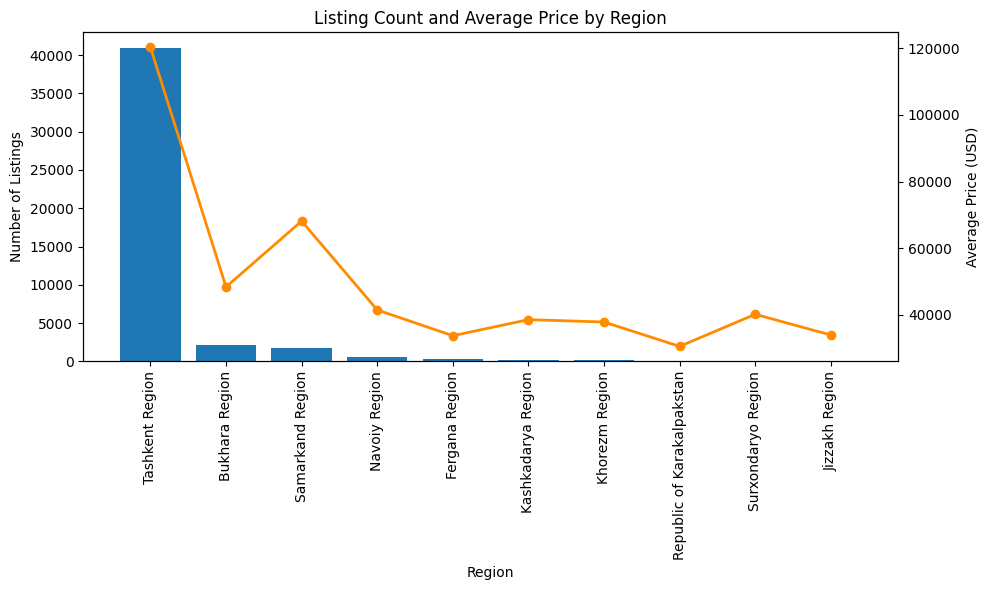

In [ ]:
# bar + line chart in pandas

# 1. Malumotlarni tayorlash
regions_pop = sale_df.groupby("region")["listing_id"].count().sort_values(ascending=False).head(10)
indexes = regions_pop.index
values_region = regions_pop.values

avg_val_region = sale_df.groupby("region")["price_usd"].mean()

# Make sure average prices follow the same region order as bars
avg_val_region = avg_val_region.reindex(indexes)

# 2. Create figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Bar chart (listing count)
ax1.bar(indexes, values_region, label="Listing Count")
ax1.set_ylabel("Number of Listings")
ax1.set_xlabel("Region")

# 4. Line chart (average price)
ax2 = ax1.twinx()
ax2.plot(indexes, avg_val_region.values, marker="o", linewidth=2, color="darkorange")
ax2.set_ylabel("Average Price (USD)")

# 5. Formatting
plt.title("Listing Count and Average Price by Region")
ax1.tick_params(axis='x', rotation=90)
plt.tight_layout()

plt.show()

In [43]:
tash_sale_df = sale_df.query("region == 'Tashkent Region'").copy()



In [48]:
# 1. Malumotlarni tozalash

tash_sale_df.groupby('district')["price_per_sqr"].mean().sort_values(ascending=False).round(2).head(10)

district
Shaykhantakhur    2543.11
Mirabad           2175.03
Yakkasaray        1913.58
Salar             1906.17
Yunusabad         1640.63
Mirzo Ulugbek     1639.22
Tashmore          1592.38
Yashnabad         1476.20
Chilanzar         1455.93
Durmen            1345.13
Name: price_per_sqr, dtype: float64